<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# 06b — Upload the uncertainty queue to the platform

Sibling of `06_upload_to_platform.ipynb`. Where `06` uploads clips the
two models *agree* on (high-confidence pre-labels for fast review),
this notebook uploads the **uncertainty queue** built in
`04_score_own_model.ipynb` — the clips whose `model_prob` sits closest
to the operating threshold. By construction these are the rows the
current zh checkpoint is least sure about; hand-labeling them gives
the next training round dense supervision exactly along the decision
boundary, where F1 is leaking.

Each row is posted as `source = 'pre_labeled'` with the model's
tentative label and a `confidence` score derived from `model_prob`.
Because uncertain clips are by definition close to the threshold,
their per-row confidence will sit roughly in `[0.3, 0.7]` — much lower
than `06`'s agreed pool. That's intentional: the records-UI triage
view orders by confidence ASC, so these will surface to reviewers
before the gold-grade rows from `06`.

## What this notebook needs

Same prerequisites as `06_upload_to_platform.ipynb` — see the setup
section there for the full token-mint flow. In short: a `wkcli_…`
token in `WAVEKAT_API_TOKEN`, the destination project's id in
`WAVEKAT_PROJECT_ID`, and an active label set with `continuation` and
`end_of_turn` keys. The only new prerequisite is
`datasets/smart-turn-zh-mining/uncertainty_queue.parquet` (run
`04_score_own_model.ipynb` end-to-end first).

In [14]:
from __future__ import annotations

import hashlib
import io
import os
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import soundfile as sf
from tqdm.auto import tqdm

MINING_ROOT       = Path("../../datasets/smart-turn-zh-mining").resolve()
UNCERTAINTY_IN    = MINING_ROOT / "uncertainty_queue.parquet"
WAV_DIR           = Path("../../datasets/MagicData-RAMC/MDT2021S003/WAV").resolve()

# Load WAVEKAT_* from a `.env` walking up from this notebook (same pattern
# as 06). `override=False` so an already-exported shell value wins.
try:
    from dotenv import find_dotenv, load_dotenv
    dotenv_path = find_dotenv(usecwd=True)
    if dotenv_path:
        load_dotenv(dotenv_path, override=False)
        print(f"loaded .env  : {Path(dotenv_path).name} (from {Path(dotenv_path).parent.name}/)")
    else:
        print("loaded .env  : (none found — relying on shell environment)")
except ImportError:
    print("loaded .env  : (python-dotenv not installed — relying on shell environment)")

PLATFORM_BASE_URL = os.environ.get("WAVEKAT_API_URL", "https://localhost:5020").rstrip("/")
PLATFORM_TOKEN    = os.environ.get("WAVEKAT_API_TOKEN")
PROJECT_ID        = os.environ.get("WAVEKAT_PROJECT_ID")

# Cap the upload run. Uncertainty queues are intentionally small
# (200–500 clips) so the default cap matters less than in 06; it's still
# here so MAX_UPLOADS=10 gives you a quick smoke test.
MAX_UPLOADS = int(os.environ.get("MAX_UPLOADS", "100000"))

LABEL_KEY_BY_PRED = {0: "continuation", 1: "end_of_turn"}

print(f"uncertainty parquet : {UNCERTAINTY_IN.name} (exists={UNCERTAINTY_IN.exists()})")
print(f"wav dir             : {WAV_DIR.name}/  (exists={WAV_DIR.exists()})")
print(f"platform            : {PLATFORM_BASE_URL}")
print(f"token set           : {bool(PLATFORM_TOKEN)}")
print(f"project id          : {PROJECT_ID or '(unset — set WAVEKAT_PROJECT_ID)'}")
print(f"max uploads         : {MAX_UPLOADS}")
print("✅ config loaded")

loaded .env  : .env (from wavekat-lab/)
uncertainty parquet : uncertainty_queue.parquet (exists=True)
wav dir             : WAV/  (exists=True)
platform            : https://platform.wavekat.com
token set           : True
project id          : 3040f61d-f6cb-4dd7-87e2-22b575d64a3c
max uploads         : 100000
✅ config loaded


In [15]:
# Ping /api/me — the cheapest possible "does my token work?" check.
# A 401 here means the token is wrong / revoked / minted against a
# different platform host.
if not PLATFORM_TOKEN:
    raise SystemExit("WAVEKAT_API_TOKEN is unset — mint one with `wk login --base-url …` and export it.")

session = requests.Session()
session.headers.update({
    "Authorization": f"Bearer {PLATFORM_TOKEN}",
    "User-Agent": "wavekat-lab/06b-upload-uncertainty",
})

me = session.get(f"{PLATFORM_BASE_URL}/api/me", timeout=10)
if me.status_code == 401:
    raise SystemExit(
        f"401 from {PLATFORM_BASE_URL}/api/me — token rejected.\n"
        f"  • Was the token minted against this host? (tokens are scoped to a single platform.)\n"
        f"  • Has it been revoked? Mint a fresh one: `WK_BASE_URL={PLATFORM_BASE_URL} wk login`."
    )
me.raise_for_status()
me_json = me.json()
print(f"authenticated as : {me_json.get('login')}  (role={me_json.get('role')}, id={me_json.get('id')})")
print("✅ token works")

authenticated as : wavekat-eason  (role=root, id=220911746)
✅ token works


In [16]:
# Verify the destination project + its active label set. Split out from the
# /me ping so a project-config issue doesn't masquerade as an auth failure.
if not PROJECT_ID:
    raise SystemExit("WAVEKAT_PROJECT_ID is unset — set it to the destination project's id.")

proj = session.get(f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}", timeout=10)
if proj.status_code == 404:
    raise SystemExit(
        f"404 on project {PROJECT_ID} — either the id is wrong, or your account "
        f"isn't a member of that project (the API returns 404, not 403, to avoid leaking existence)."
    )
proj.raise_for_status()
proj_json = proj.json()
print(f"project          : {proj_json.get('name')}  (role={proj_json.get('myRoleInProject')})")
active_label_set_id = proj_json.get("activeLabelSetId")
if not active_label_set_id:
    raise SystemExit("project has no active label set — pick one in the platform UI first.")

ls = session.get(f"{PLATFORM_BASE_URL}/api/label-sets/{active_label_set_id}", timeout=10)
ls.raise_for_status()
ls_json = ls.json()
label_keys = {l["key"] for l in ls_json.get("labels", [])}
missing = set(LABEL_KEY_BY_PRED.values()) - label_keys
if missing:
    raise SystemExit(
        f"active label set '{ls_json.get('name')}' is missing required keys: {sorted(missing)}"
    )
print(f"label set        : {ls_json.get('name')}  (keys: {sorted(label_keys)})")
print("✅ project + label set verified")

project          : MagicData-RAMC - Auto Label #3  (role=root)
label set        : Turn Detection V1  (keys: ['continuation', 'end_of_turn'])
✅ project + label set verified


In [17]:
# Build the upload queue directly from `uncertainty_queue.parquet`. No
# band filter, no stratified sample, no targeted-pick override — the
# queue is already a fixed-size, session-diversified, near-threshold
# selection (see `04_score_own_model.ipynb`'s uncertainty-queue cell).
#
# Platform `confidence` follows the same semantics as 06: the model's
# probability of the *assigned* label. Because every row here sits near
# the F1-tuned threshold, confidence will be middling (~0.3–0.7) — well
# below 1.0 by design. That's exactly what we want: the records-UI
# orders auto-labelled rows by confidence ASC, so these surface to
# reviewers before any high-confidence imports.
queue = pd.read_parquet(UNCERTAINTY_IN)
queue["duration_s"] = (queue["clip_end_s"] - queue["clip_start_s"]).astype(float)

mp = queue["model_prob"].astype(float)
is_eot = queue["model_pred"] == 1
queue["confidence"] = np.where(is_eot, mp, 1.0 - mp)

to_upload = queue.head(MAX_UPLOADS).reset_index(drop=True)

print(f"queue rows        : {len(queue)}")
print(f"queued for upload : {len(to_upload)}  (cap MAX_UPLOADS={MAX_UPLOADS})")
print("by tentative label (queued):")
for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
    n = int((to_upload["model_pred"] == pred).sum())
    print(f"    {label_key:>12} : {n}")
if len(to_upload):
    print(f"confidence range  : "
          f"min={to_upload['confidence'].min():.3f}, "
          f"median={to_upload['confidence'].median():.3f}, "
          f"max={to_upload['confidence'].max():.3f}")
    if "distance_to_threshold" in to_upload.columns:
        d = to_upload["distance_to_threshold"].astype(float)
        print(f"Δthreshold range  : min={d.min():.4f}, median={d.median():.4f}, max={d.max():.4f}")
    print(f"duration range    : "
          f"min={to_upload['duration_s'].min():.3f}s, "
          f"max={to_upload['duration_s'].max():.3f}s")
    n_disagree = int((to_upload["model_pred"] != to_upload["label"]).sum())
    print(f"model vs structural disagreement : {n_disagree} / {len(to_upload)}")
print("✅ upload queue ready")

queue rows        : 300
queued for upload : 300  (cap MAX_UPLOADS=100000)
by tentative label (queued):
    continuation : 115
     end_of_turn : 185
confidence range  : min=0.290, median=0.714, max=0.745
Δthreshold range  : min=0.0001, median=0.0103, max=0.0353
duration range    : min=1.000s, max=8.000s
model vs structural disagreement : 152 / 300
✅ upload queue ready


queued clips     : 300
duration min     : 1.000s
duration p50     : 2.408s
duration p90     : 5.637s
duration p99     : 8.000s
duration max     : 8.000s
✅ all clips ≤ 8s — match the model's input window and the platform's bucketing


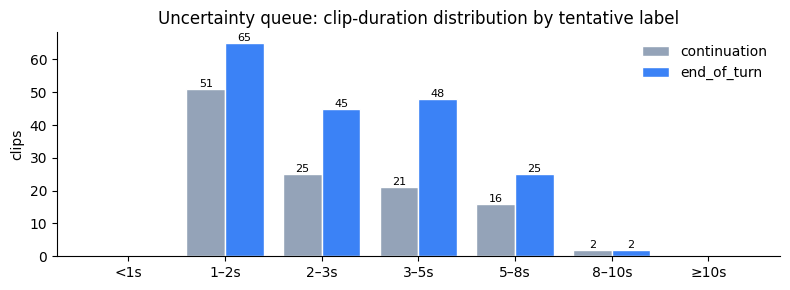

✅ duration distribution preview — run the upload cell when satisfied


In [18]:
# Pre-flight chart: clip-duration distribution of the queued sample,
# split by tentative label. Buckets line up with the records-UI
# duration filter so the chart and the platform tell the same story.
import matplotlib.pyplot as plt

DURATION_EDGES  = [0.0, 1.0, 2.0, 3.0, 5.0, 8.0, 10.0, float("inf")]
DURATION_LABELS = ["<1s", "1–2s", "2–3s", "3–5s", "5–8s", "8–10s", "≥10s"]

durations = (to_upload["clip_end_s"] - to_upload["clip_start_s"]).astype(float)
print(f"queued clips     : {len(durations)}")
if len(durations):
    print(f"duration min     : {durations.min():.3f}s")
    print(f"duration p50     : {durations.median():.3f}s")
    print(f"duration p90     : {durations.quantile(0.90):.3f}s")
    print(f"duration p99     : {durations.quantile(0.99):.3f}s")
    print(f"duration max     : {durations.max():.3f}s")

n_over_8 = int((durations > 8.0).sum())
if n_over_8:
    print(f"⚠️  {n_over_8} clip(s) exceed 8s — the platform's duration filter "
          f"will lump these into its ≥10s bucket")
elif len(durations):
    print("✅ all clips ≤ 8s — match the model's input window and the platform's bucketing")

counts_by_label: dict[str, np.ndarray] = {}
for pred, label_key in sorted(LABEL_KEY_BY_PRED.items()):
    sub = to_upload[to_upload["model_pred"] == pred]
    d = (sub["clip_end_s"] - sub["clip_start_s"]).astype(float)
    c, _ = np.histogram(d, bins=DURATION_EDGES)
    counts_by_label[label_key] = c

fig, ax = plt.subplots(figsize=(8, 3.0))
x = np.arange(len(DURATION_LABELS))
w = 0.4
palette = {"continuation": "#94a3b8", "end_of_turn": "#3b82f6"}
for i, (label_key, c) in enumerate(counts_by_label.items()):
    offset = (i - (len(counts_by_label) - 1) / 2) * w
    bars = ax.bar(x + offset, c, w, label=label_key,
                  color=palette.get(label_key), edgecolor="white")
    for bar, v in zip(bars, c):
        if v:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{int(v)}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(DURATION_LABELS)
ax.set_ylabel("clips")
ax.set_title("Uncertainty queue: clip-duration distribution by tentative label")
ax.legend(loc="upper right", frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
print("✅ duration distribution preview — run the upload cell when satisfied")

In [19]:
# Per-session helpers — same as 06: hash the WAV once, cache the file id,
# slice + re-emit a 16-bit mono PCM WAV per clip.
import functools

_HASH_CHUNK = 1024 * 1024  # 1 MB

@functools.lru_cache(maxsize=None)
def session_wav_meta(session_id: str) -> dict:
    path = WAV_DIR / f"{session_id}.wav"
    info = sf.info(str(path))
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(_HASH_CHUNK)
            if not chunk:
                break
            h.update(chunk)
    return {
        "path": path,
        "sha256": h.hexdigest(),
        "sample_rate": int(info.samplerate),
        "channels": int(info.channels),
        "duration_sec": float(info.frames) / float(info.samplerate),
    }

@functools.lru_cache(maxsize=None)
def upsert_file(session_id: str) -> str:
    """Create-or-get the platform `files` row for a session WAV; return its id."""
    meta = session_wav_meta(session_id)
    body = {
        "name": session_id,
        "originalFilename": f"{session_id}.wav",
        "sha256": meta["sha256"],
        "durationSec": meta["duration_sec"],
        "sampleRate": meta["sample_rate"],
        "channelCount": meta["channels"],
    }
    r = session.post(
        f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}/files",
        json=body, timeout=15,
    )
    r.raise_for_status()
    j = r.json()
    return j["id"]

def slice_wav_bytes(session_id: str, start_s: float, end_s: float) -> bytes:
    meta = session_wav_meta(session_id)
    sr = meta["sample_rate"]
    start  = max(0, int(start_s * sr))
    frames = max(1, int((end_s - start_s) * sr))
    audio, _ = sf.read(str(meta["path"]), start=start, frames=frames,
                       dtype="float32", always_2d=False)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    buf = io.BytesIO()
    sf.write(buf, audio, sr, format="WAV", subtype="PCM_16")
    return buf.getvalue()

print("✅ helpers ready")

✅ helpers ready


In [20]:
# Preview the first N rows of `to_upload` as inline audio players — the
# last sanity check before firing the upload loop. These should sound
# genuinely ambiguous; if they all sound clearly yes-or-no, the model
# is uncertain on easy cases (a calibration issue, not an active-
# labeling opportunity).
from IPython.display import Audio, display, HTML

PREVIEW_N = int(os.environ.get("PREVIEW_N", "10"))
preview = to_upload.head(PREVIEW_N)
print(f"previewing {len(preview)} of {len(to_upload)} queued clips  (env: PREVIEW_N)")

for i, row in preview.iterrows():
    sid = str(row["session_id"])
    pred = int(row["model_pred"])
    label_key = LABEL_KEY_BY_PRED[pred]
    start_s = float(row["clip_start_s"])
    end_s   = float(row["clip_end_s"])
    asr_text = str(row.get("text", "") or "")
    wav_bytes = slice_wav_bytes(sid, start_s, end_s)
    structural = int(row["label"])
    structural_key = LABEL_KEY_BY_PRED.get(structural, str(structural))
    disagree = " ⚠ disagrees with structural" if structural != pred else ""
    header = (
        f"[{i + 1:02d}] tentative={label_key}  "
        f"conf={float(row['confidence']):.3f}  "
        f"prob={float(row['model_prob']):.3f}  "
        f"structural={structural_key}{disagree}  "
        f"dur={end_s - start_s:.2f}s  "
        f"{sid} @ {start_s:.2f}–{end_s:.2f}s"
    )
    display(HTML(f"<div style='font-family:ui-monospace,monospace;font-size:12px;margin-top:6px'>{header}</div>"))
    if asr_text:
        display(HTML(f"<div style='font-size:13px;color:#475569;margin-bottom:2px'>asr: {asr_text}</div>"))
    display(Audio(data=wav_bytes))
print("✅ preview rendered — scroll up to listen, then run the upload cell when satisfied")

previewing 10 of 300 queued clips  (env: PREVIEW_N)


✅ preview rendered — scroll up to listen, then run the upload cell when satisfied


In [21]:
# Upload loop. Mirrors 06's parallelised loop; the only differences are
# the notes string (single-model + structural-label context, no pipecat
# vote) and that there's no `_notes` override path because this notebook
# only feeds the uncertainty queue.
import concurrent.futures
from requests.adapters import HTTPAdapter

_adapter = HTTPAdapter(pool_connections=64, pool_maxsize=64, max_retries=0)
session.mount("https://", _adapter)
session.mount("http://", _adapter)

unique_sessions = sorted(set(to_upload["session_id"].astype(str)))
print(f"pre-warming {len(unique_sessions)} session file(s)…")
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as _ex:
    list(tqdm(_ex.map(upsert_file, unique_sessions),
              total=len(unique_sessions), desc="files", unit="file"))

UPLOAD_WORKERS = int(os.environ.get("UPLOAD_WORKERS", "16"))


def _upload_one(row_tuple):
    _, row = row_tuple
    sid = str(row["session_id"])
    pred = int(row["model_pred"])
    label_key = LABEL_KEY_BY_PRED[pred]
    confidence = float(row["confidence"])
    start_s = float(row["clip_start_s"])
    end_s   = float(row["clip_end_s"])
    asr_text = str(row.get("text", "") or "")[:4000]

    try:
        file_id = upsert_file(sid)
        d2t = row.get("distance_to_threshold")
        d2t_str = f"{float(d2t):.4f}" if d2t is not None and not pd.isna(d2t) else "n/a"
        notes = (
            f"smart-turn-mining uncertainty queue\n"
            f"model_prob={float(row['model_prob']):.4f}, "
            f"distance_to_threshold={d2t_str}, "
            f"structural_label={row.get('label')}, source={row.get('source')}"
        )
        create_body = {
            "labelKey":   label_key,
            "startSec":   start_s,
            "endSec":     end_s,
            "asrText":    asr_text or None,
            "source":     "pre_labeled",
            "confidence": confidence,
            "notes":      notes,
        }
        r = session.post(
            f"{PLATFORM_BASE_URL}/api/files/{file_id}/annotations",
            json=create_body, timeout=30,
        )
        r.raise_for_status()
        ann_id = r.json()["id"]

        wav_bytes = slice_wav_bytes(sid, start_s, end_s)
        u = session.put(
            f"{PLATFORM_BASE_URL}/api/annotations/{ann_id}/clip",
            data=wav_bytes,
            headers={"Content-Type": "audio/wav"},
            timeout=60,
        )
        u.raise_for_status()
        return {
            "ok": True, "annotation_id": ann_id, "label": label_key,
            "confidence": confidence, "bytes": len(wav_bytes),
            "session": sid, "range": f"{start_s:.2f}-{end_s:.2f}",
        }
    except requests.HTTPError as e:
        body = getattr(e.response, "text", "")
        return {
            "ok": False, "label": label_key, "confidence": confidence,
            "session": sid, "range": f"{start_s:.2f}-{end_s:.2f}",
            "error": f"HTTP {e.response.status_code}: {body[:200]}",
        }
    except Exception as e:
        return {
            "ok": False, "label": label_key, "confidence": confidence,
            "session": sid, "range": f"{start_s:.2f}-{end_s:.2f}",
            "error": f"{type(e).__name__}: {e}",
        }


results: list[dict] = []
ok_count = 0
fail_count = 0

rows = list(to_upload.iterrows())
pbar = tqdm(total=len(rows), desc="upload", unit="clip")
with concurrent.futures.ThreadPoolExecutor(max_workers=UPLOAD_WORKERS) as ex:
    for res in ex.map(_upload_one, rows):
        results.append(res)
        if res["ok"]:
            ok_count += 1
        else:
            fail_count += 1
        pbar.set_postfix(ok=ok_count, fail=fail_count, refresh=False)
        pbar.update(1)
pbar.close()

results_df = pd.DataFrame(results)
print(f"uploaded ok : {ok_count}")
print(f"failed      : {fail_count}  (workers={UPLOAD_WORKERS})")
if fail_count:
    print("\nfirst failures:")
    display(results_df[~results_df["ok"]].head(5))
print("✅ upload run complete")
results_df.head(20)

pre-warming 300 session file(s)…


files:   0%|          | 0/300 [00:00<?, ?file/s]

upload:   0%|          | 0/300 [00:00<?, ?clip/s]

uploaded ok : 265
failed      : 35  (workers=16)

first failures:


,ok,label,confidence,session,range,error,annotation_id,bytes
0,False,continuation,0.290092,CTS-CN-F2F-2019-11-15-240,1406.07-1408.51,"HTTP 409: {""id"":""3ea88238-3093-440a-ba94-f7ef1...",NaN,NaN
1,False,end_of_turn,0.710115,CTS-CN-F2F-2019-11-15-1191,1574.45-1581.06,"HTTP 409: {""id"":""7f9da38b-0e1a-4b44-994f-0724e...",NaN,NaN
3,False,continuation,0.290305,CTS-CN-F2F-2019-11-15-926,350.50-353.41,"HTTP 409: {""id"":""8fb3ecb1-bb57-4e31-829a-dc8fa...",NaN,NaN
4,False,end_of_turn,0.710311,CTS-CN-F2F-2019-11-15-142,77.59-78.85,"HTTP 409: {""id"":""ac07c54a-a391-4e6b-a727-e31a7...",NaN,NaN
6,False,continuation,0.290477,CTS-CN-F2F-2019-11-15-1470,1137.48-1138.53,"HTTP 409: {""id"":""20150558-0f69-44a0-8424-60ee4...",NaN,NaN


✅ upload run complete


,ok,label,confidence,session,range,error,annotation_id,bytes
0,False,continuation,0.290092,CTS-CN-F2F-2019-11-15-240,1406.07-1408.51,"HTTP 409: {""id"":""3ea88238-3093-440a-ba94-f7ef1...",NaN,NaN
1,False,end_of_turn,0.710115,CTS-CN-F2F-2019-11-15-1191,1574.45-1581.06,"HTTP 409: {""id"":""7f9da38b-0e1a-4b44-994f-0724e...",NaN,NaN
2,True,continuation,0.290206,CTS-CN-F2F-2019-11-15-503,1214.18-1216.35,NaN,4df4e439-b1ab-4330-8028-424c069c1b8e,69676.0
3,False,continuation,0.290305,CTS-CN-F2F-2019-11-15-926,350.50-353.41,"HTTP 409: {""id"":""8fb3ecb1-bb57-4e31-829a-dc8fa...",NaN,NaN
4,False,end_of_turn,0.710311,CTS-CN-F2F-2019-11-15-142,77.59-78.85,"HTTP 409: {""id"":""ac07c54a-a391-4e6b-a727-e31a7...",NaN,NaN
5,True,continuation,0.290465,CTS-CN-F2F-2019-11-15-500,596.53-597.60,NaN,db37970d-1b8b-46a8-8553-93471dd676c6,34412.0
6,False,continuation,0.290477,CTS-CN-F2F-2019-11-15-1470,1137.48-1138.53,"HTTP 409: {""id"":""20150558-0f69-44a0-8424-60ee4...",NaN,NaN
7,True,end_of_turn,0.710491,CTS-CN-F2F-2019-11-15-539,496.11-497.25,NaN,23365697-1aa9-468f-bb66-e2069866ebaf,36332.0
8,True,continuation,0.290502,CTS-CN-F2F-2019-11-15-894,1618.09-1619.26,NaN,f06f8dba-68c9-4745-94ca-5751c1e45b98,37674.0
9,False,continuation,0.290514,CTS-CN-F2F-2019-11-15-602,1322.22-1326.72,"HTTP 409: {""id"":""dada82c4-5dad-4b1d-bf0e-5c1b8...",NaN,NaN


In [22]:
# Sanity-check: re-fetch the project's auto-labelled rows ordered by
# confidence ASC. The freshly-uploaded uncertainty rows should sit near
# the top of this list — that's the whole reason we used a low-ish
# confidence score: reviewers triage them first.
r = session.get(
    f"{PLATFORM_BASE_URL}/api/projects/{PROJECT_ID}/annotations",
    params={
        "page": 1,
        "pageSize": 20,
        "source": "auto",
        "orderBy": "confidence",
        "order": "asc",
    },
    timeout=15,
)
r.raise_for_status()
page = r.json()
print(f"project auto-labelled total : {page['total']}")
if page['annotations']:
    cols = ["labelKey", "confidence", "reviewStatus", "startSec", "endSec", "fileName"]
    display(pd.DataFrame(page['annotations'])[cols].head(20))
print("✅ verified via the records-list endpoint")

project auto-labelled total : 2025


,labelKey,confidence,reviewStatus,startSec,endSec,fileName
0,continuation,0.267426,rejected,85.613,91.040,CTS-CN-F2F-2019-11-15-77
1,end_of_turn,0.269797,approved,660.992,662.400,CTS-CN-F2F-2019-11-15-520
2,end_of_turn,0.284898,approved,1220.052,1221.120,CTS-CN-F2F-2019-11-15-714
3,continuation,0.290206,NaN,1214.176,1216.352,CTS-CN-F2F-2019-11-15-503
4,end_of_turn,0.290206,approved,1214.176,1216.352,CTS-CN-F2F-2019-11-15-503
5,continuation,0.290305,approved,350.497,353.408,CTS-CN-F2F-2019-11-15-926
6,end_of_turn,0.290465,approved,596.526,597.600,CTS-CN-F2F-2019-11-15-500
7,continuation,0.290465,NaN,596.526,597.600,CTS-CN-F2F-2019-11-15-500
8,continuation,0.290477,rejected,1137.484,1138.528,CTS-CN-F2F-2019-11-15-1470
9,end_of_turn,0.290502,approved,1618.088,1619.264,CTS-CN-F2F-2019-11-15-894


✅ verified via the records-list endpoint
